<a href="https://colab.research.google.com/github/shubh-1009/MLE-LABS/blob/main/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('house_prices_practice.csv')

preview first 5 rows

In [3]:
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


preview last 5 rows

In [4]:
df.tail()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
295,296,1,3495,1,1792,1954,2,5,4978,250604
296,297,5,3438,3,1266,2003,0,1,9373,329906
297,298,6,1992,0,1148,1996,1,1,7907,184623
298,299,3,3722,1,1407,1998,1,1,8097,303345
299,300,9,1667,0,988,1958,2,1,14553,204982


check no of rows and columns

In [5]:
df.shape

(300, 10)

check column data types and non-null counts

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


summary of dataset

In [7]:
df.describe()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


check for missing values in eac column

In [8]:
print(df.isnull().sum())

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64


check for duplicate rows

In [9]:
print(df.duplicated().sum())

0


In [10]:
x = df['GrLivArea'].values
y = df['SalePrice'].values

x_norm = (x - x.min()) / x.std()

train with gradient descent

In [11]:
m = len(y)
theta0, theta1 = 0.0,0.0
eta=0.1
iterations= 500

for i in range(iterations):
  y_pred = theta0 + theta1 * x_norm
  error = y_pred - y
  theta0 -= eta * (1/m) * np.sum(error)
  theta1 -= eta * (1/m) * np.sum(error * x_norm)

print("Theta0: ",theta0)
print("Theta1: ",theta1)

Theta0:  155599.64806300355
Theta1:  55788.72850847338


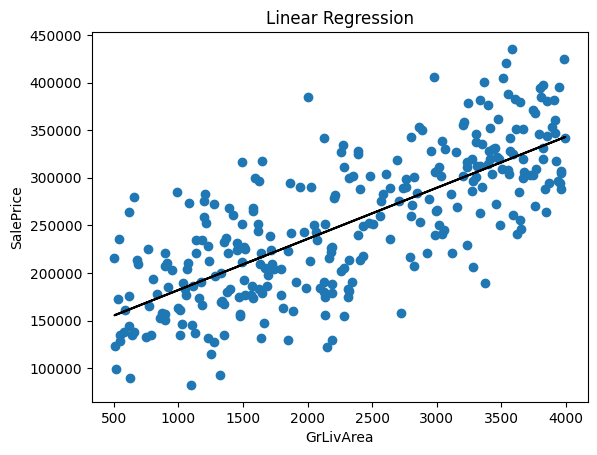

In [12]:
plt.scatter(x,y)
plt.plot(x,theta0+theta1*x_norm,color='black')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title("Linear Regression")
plt.show()

using scikit-learn

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,accuracy_score

In [14]:
X = df.drop(['Id', 'SalePrice'],axis=1)
y = df['SalePrice']

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test)

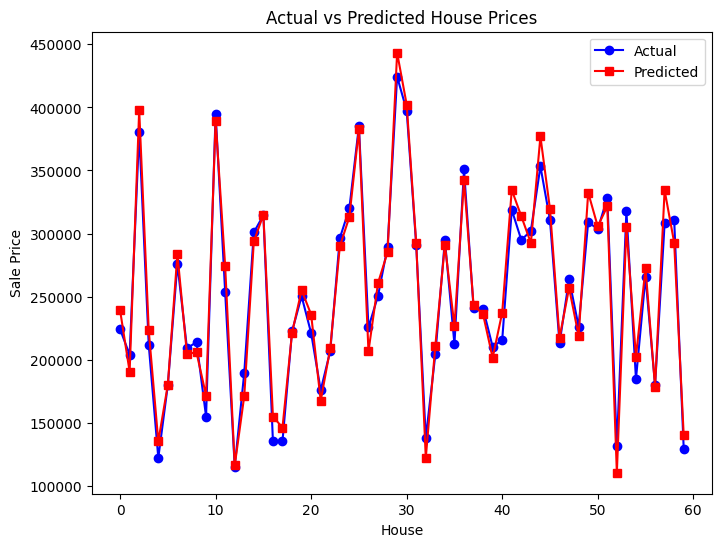

In [18]:
plt.figure(figsize=(8,6))
plt.plot(y_test.values, color='blue', marker='o',label='Actual')
plt.plot(y_pred, color='red', marker='s',label='Predicted')
plt.xlabel("House")
plt.ylabel("Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()

In [19]:
r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rsme = np.sqrt(mean_squared_error(y_test,y_pred))
print("R2 Score: ",round(r2,4))
print("MAE: ",round(mae,4))
print("RMSE: ",round(rsme,4))

R2 Score:  0.9724
MAE:  10431.656
RMSE:  12505.4593
